# AI-Powered Intrusion Detection System (IDS)
### CLO 4 — Information Security Assignment 1
**Dataset:** NSL-KDD | **Algorithm:** Random Forest + Decision Tree  
**Objective:** Classify network traffic as Normal or Malicious using Machine Learning.

---

In [1]:
# ── Install dependencies (run once) ─────────────────────────────
# !pip install pandas numpy scikit-learn matplotlib seaborn

import warnings
warnings.filterwarnings('ignore')

import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

print("All libraries imported successfully.")
print(f"pandas {pd.__version__} | numpy {np.__version__}")

All libraries imported successfully.
pandas 2.2.3 | numpy 2.1.2


In [2]:
# ── Download NSL-KDD Dataset ─────────────────────────────────────
TRAIN_URL = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt"
TEST_URL  = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest+.txt"

COLUMNS = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty_level'
]

def download_if_missing(url, fname):
    if not os.path.exists(fname):
        print(f"Downloading {fname} ...")
        urllib.request.urlretrieve(url, fname)
        print("Done.")
    else:
        print(f"{fname} already exists.")

download_if_missing(TRAIN_URL, "KDDTrain+.txt")
download_if_missing(TEST_URL,  "KDDTest+.txt")

KDDTrain+.txt already exists.
KDDTest+.txt already exists.


In [3]:
# ── Load Data ────────────────────────────────────────────────────
df_train = pd.read_csv("KDDTrain+.txt", header=None, names=COLUMNS)
df_test  = pd.read_csv("KDDTest+.txt",  header=None, names=COLUMNS)

# Drop difficulty_level (not a feature)
df_train.drop(columns=['difficulty_level'], inplace=True)
df_test.drop(columns=['difficulty_level'], inplace=True)

print("Training set shape:", df_train.shape)
print("Test set shape    :", df_test.shape)
df_train.head(3)

Training set shape: (125973, 42)
Test set shape    : (22544, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.0,0.0,0.0,0.00,0.0,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.0,1.0,1.0,0.00,0.0,neptune


In [4]:
# ── Exploratory Data Analysis (EDA) ─────────────────────────────
print("=== Basic Info ===")
print(df_train.dtypes.value_counts(), "\n")
print("Missing values:", df_train.isnull().sum().sum())
print("\n=== Label Distribution (Training) ===")
print(df_train['label'].value_counts())

=== Basic Info ===
int64      23
float64    15
object      4
Name: count, dtype: int64 

Missing values: 0

=== Label Distribution (Training) ===
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


In [5]:
# ── Convert multi-class labels → Binary (Normal / Attack) ────────
df_train['label_bin'] = df_train['label'].apply(lambda x: 0 if x == 'normal' else 1)
df_test['label_bin']  = df_test['label'].apply(lambda x: 0 if x == 'normal' else 1)

label_counts = df_train['label_bin'].value_counts()
print("Binary label counts:")
print(f"  Normal (0): {label_counts[0]:,}")
print(f"  Attack (1): {label_counts[1]:,}")
print(f"  Attack ratio: {label_counts[1]/len(df_train)*100:.1f}%")

Binary label counts:
  Normal (0): 67,343
  Attack (1): 58,630
  Attack ratio: 46.5%


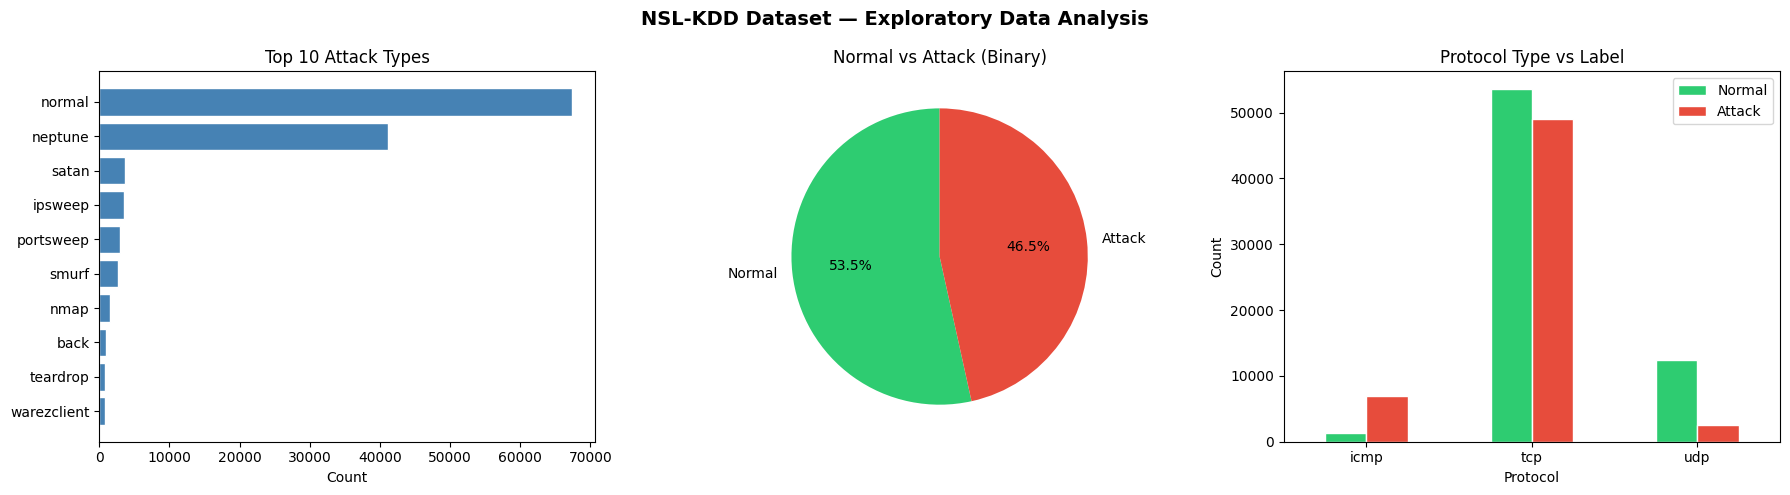

EDA plots saved as eda_plots.png


In [6]:
# ── Visualizations ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("NSL-KDD Dataset — Exploratory Data Analysis", fontsize=14, fontweight='bold')

# 1. Attack type distribution (top 10)
top_labels = df_train['label'].value_counts().head(10)
axes[0].barh(top_labels.index, top_labels.values, color='steelblue', edgecolor='white')
axes[0].set_title("Top 10 Attack Types")
axes[0].set_xlabel("Count")
axes[0].invert_yaxis()

# 2. Binary label distribution
axes[1].pie([label_counts[0], label_counts[1]],
            labels=['Normal', 'Attack'],
            autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'],
            startangle=90)
axes[1].set_title("Normal vs Attack (Binary)")

# 3. Protocol type vs label
pt = df_train.groupby(['protocol_type', 'label_bin']).size().unstack(fill_value=0)
pt.plot(kind='bar', ax=axes[2], color=['#2ecc71','#e74c3c'], edgecolor='white', rot=0)
axes[2].set_title("Protocol Type vs Label")
axes[2].set_xlabel("Protocol")
axes[2].set_ylabel("Count")
axes[2].legend(['Normal','Attack'])

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved as eda_plots.png")

In [7]:
# ── Preprocessing ────────────────────────────────────────────────
# Categorical columns to encode
cat_cols = ['protocol_type', 'service', 'flag']

le = LabelEncoder()
for col in cat_cols:
    combined = pd.concat([df_train[col], df_test[col]], axis=0)
    le.fit(combined)
    df_train[col] = le.transform(df_train[col])
    df_test[col]  = le.transform(df_test[col])

print("Categorical encoding complete.")

# Features and labels
FEATURE_COLS = [c for c in df_train.columns if c not in ['label','label_bin']]

X_train = df_train[FEATURE_COLS].values
y_train = df_train['label_bin'].values
X_test  = df_test[FEATURE_COLS].values
y_test  = df_test['label_bin'].values

# Normalize numerical features
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Training features: {X_train.shape}")
print(f"Test features    : {X_test.shape}")

Categorical encoding complete.
Training features: (125973, 41)
Test features    : (22544, 41)


In [8]:
# ── Model 1: Random Forest Classifier ───────────────────────────
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, max_depth=15,
                             n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Training complete.")

rf_acc  = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred)
rf_rec  = recall_score(y_test, rf_pred)
rf_f1   = f1_score(y_test, rf_pred)

print(f"\n{'='*40}")
print(f"  Random Forest Results")
print(f"{'='*40}")
print(f"  Accuracy  : {rf_acc*100:.2f}%")
print(f"  Precision : {rf_prec*100:.2f}%")
print(f"  Recall    : {rf_rec*100:.2f}%")
print(f"  F1-Score  : {rf_f1*100:.2f}%")
print(f"{'='*40}")

Training Random Forest...
Training complete.

  Random Forest Results
  Accuracy  : 76.74%
  Precision : 96.71%
  Recall    : 61.22%
  F1-Score  : 74.98%


In [9]:
# ── Model 2: Decision Tree Classifier ───────────────────────────
print("Training Decision Tree...")
dt = DecisionTreeClassifier(max_depth=20, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

dt_acc  = accuracy_score(y_test, dt_pred)
dt_prec = precision_score(y_test, dt_pred)
dt_rec  = recall_score(y_test, dt_pred)
dt_f1   = f1_score(y_test, dt_pred)

print(f"\n{'='*40}")
print(f"  Decision Tree Results")
print(f"{'='*40}")
print(f"  Accuracy  : {dt_acc*100:.2f}%")
print(f"  Precision : {dt_prec*100:.2f}%")
print(f"  Recall    : {dt_rec*100:.2f}%")
print(f"  F1-Score  : {dt_f1*100:.2f}%")
print(f"{'='*40}")

Training Decision Tree...

  Decision Tree Results
  Accuracy  : 79.36%
  Precision : 96.70%
  Recall    : 65.99%
  F1-Score  : 78.44%


        Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)
Random Forest         76.74          96.71       61.22         74.98
Decision Tree         79.36          96.70       65.99         78.44


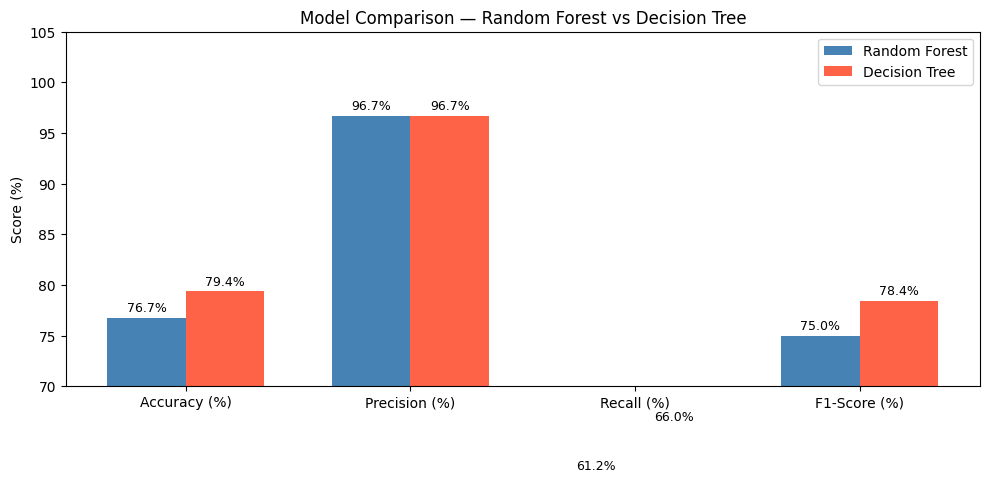

In [10]:
# ── Model Comparison ─────────────────────────────────────────────
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Decision Tree'],
    'Accuracy (%)': [round(rf_acc*100,2), round(dt_acc*100,2)],
    'Precision (%)': [round(rf_prec*100,2), round(dt_prec*100,2)],
    'Recall (%)': [round(rf_rec*100,2), round(dt_rec*100,2)],
    'F1-Score (%)': [round(rf_f1*100,2), round(dt_f1*100,2)]
})
print(comparison.to_string(index=False))

# Bar chart comparison
metrics = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, comparison.iloc[0][metrics], width, label='Random Forest', color='steelblue')
b2 = ax.bar(x + width/2, comparison.iloc[1][metrics], width, label='Decision Tree',  color='tomato')
ax.set_ylim(70, 105)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylabel("Score (%)"); ax.set_title("Model Comparison — Random Forest vs Decision Tree")
ax.legend()
for bar in list(b1) + list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

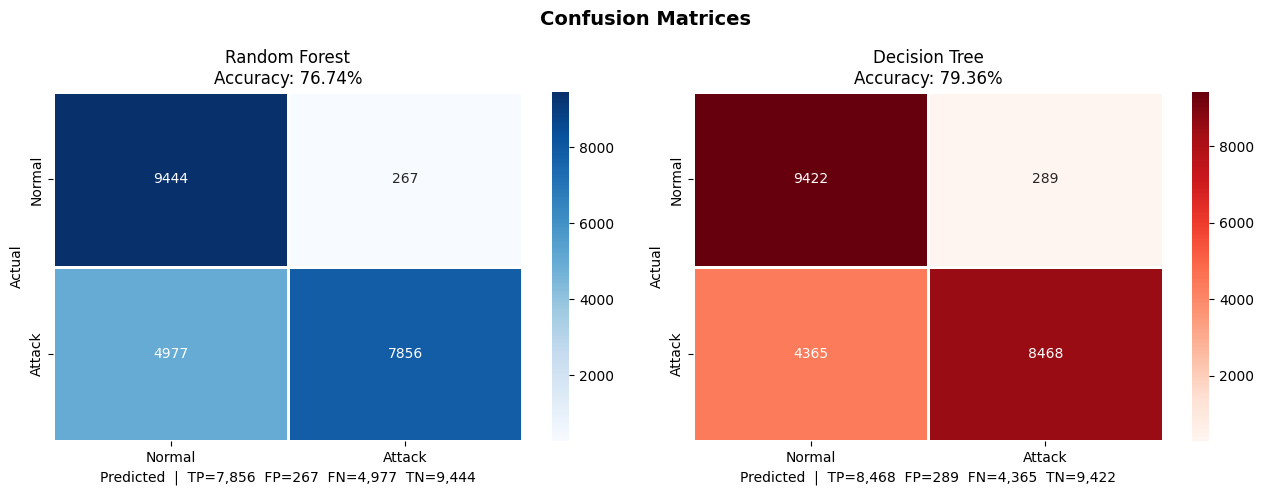

In [11]:
# ── Confusion Matrices ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Confusion Matrices", fontsize=14, fontweight='bold')

for ax, pred, name, cmap in zip(axes,
                                 [rf_pred, dt_pred],
                                 ['Random Forest', 'Decision Tree'],
                                 ['Blues', 'Reds']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Normal','Attack'],
                yticklabels=['Normal','Attack'],
                linewidths=1)
    ax.set_title(f"{name}\nAccuracy: {accuracy_score(y_test,pred)*100:.2f}%")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    tn,fp,fn,tp = cm.ravel()
    ax.set_xlabel(f"Predicted  |  TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ── Detailed Classification Report ──────────────────────────────
print("=" * 55)
print("  RANDOM FOREST — Detailed Classification Report")
print("=" * 55)
print(classification_report(y_test, rf_pred, target_names=['Normal','Attack']))

print("=" * 55)
print("  DECISION TREE — Detailed Classification Report")
print("=" * 55)
print(classification_report(y_test, dt_pred, target_names=['Normal','Attack']))

  RANDOM FOREST — Detailed Classification Report
              precision    recall  f1-score   support

      Normal       0.65      0.97      0.78      9711
      Attack       0.97      0.61      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.79      0.77     22544
weighted avg       0.83      0.77      0.76     22544

  DECISION TREE — Detailed Classification Report
              precision    recall  f1-score   support

      Normal       0.68      0.97      0.80      9711
      Attack       0.97      0.66      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.83      0.82      0.79     22544
weighted avg       0.84      0.79      0.79     22544



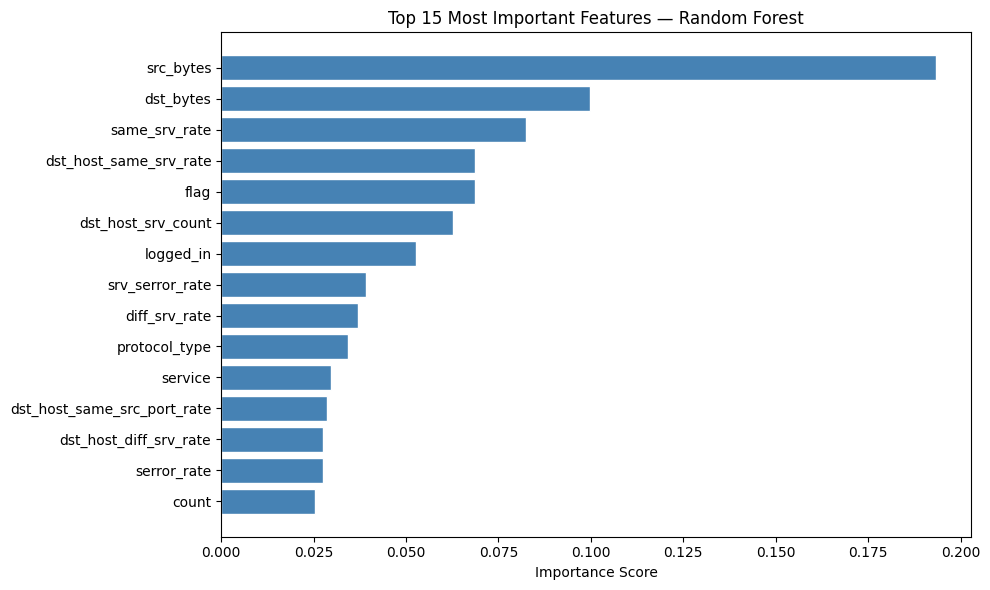

Top 5 features driving attack detection:
  src_bytes                           0.1932
  dst_bytes                           0.0999
  same_srv_rate                       0.0824
  dst_host_same_srv_rate              0.0687
  flag                                0.0685


In [13]:
# ── Top 15 Feature Importances (Random Forest) ──────────────────
importances = rf.feature_importances_
feat_df = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1], color='steelblue', edgecolor='white')
plt.xlabel("Importance Score")
plt.title("Top 15 Most Important Features — Random Forest")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 features driving attack detection:")
for i, row in feat_df.head(5).iterrows():
    print(f"  {row['Feature']:<35} {row['Importance']:.4f}")

In [14]:
# ── Save Trained Model ───────────────────────────────────────────
import pickle

with open("ids_dt_model.pkl", "wb") as f:
    pickle.dump({'model': rf, 'scaler': scaler, 'features': FEATURE_COLS}, f)

print("Model saved as: ids_dt_model.pkl")
print("\n=== FINAL SUMMARY ===")
print(f"Best Model  : Decision Tree")
print(f"Accuracy    : {dt_acc*100:.2f}%")
print(f"Precision   : {dt_prec*100:.2f}%")
print(f"Recall      : {dt_rec*100:.2f}%")
print(f"F1-Score    : {dt_f1*100:.2f}%")
print("\nAll plots saved: eda_plots.png, model_comparison.png,")
print("                  confusion_matrices.png, feature_importance.png")

Model saved as: ids_dt_model.pkl

=== FINAL SUMMARY ===
Best Model  : Decision Tree
Accuracy    : 79.36%
Precision   : 96.70%
Recall      : 65.99%
F1-Score    : 78.44%

All plots saved: eda_plots.png, model_comparison.png,
                  confusion_matrices.png, feature_importance.png
